In [1]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error, balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, make_scorer, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps, focal_binary_loss
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, HalvingGridSearchCV, GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from collections import Counter

In [2]:
# Data preparation
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")

hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT',
        'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

# exclude NAs
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
plast_chem_hazard = plast_chem_hazard.where(plast_chem_hazard['Hazard_information_Toxicity_score'] != 0.25)

# include NAs → test for sparsity algo
#plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
#plast_chem_hazard = plast_chem.where(plast_chem['Hazard_information_Toxicity_score'] != 0.25)

print(plast_chem_hazard['Hazard_information_Hazard_score'].value_counts())

# fingerprints
fps = calculate_mfps(plast_chem_hazard, 'Properties_isomeric_smiles')

mask = [fp is not None for fp in fps]
plast_chem_hazard = plast_chem_hazard[mask].copy()
fps = [fp for fp in fps if fp is not None]

X = np.vstack(fps)

Hazard_information_Hazard_score
2.0    3049
0.5    1188
1.0    1041
0.0     161
Name: count, dtype: int64


[12:12:12] WARNING: not removing hydrogen atom without neighbors
[12:12:12] WARNING: not removing hydrogen atom without neighbors
[12:12:12] WARNING: not removing hydrogen atom without neighbors
[12:12:12] WARNING: not removing hydrogen atom without neighbors
[12:12:12] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] WARNING: not removing hydrogen atom without neighbors
[12:12:13] Explicit valen

## binary
- focus on binary, multiclass as extension

In [3]:
# less hazardous and hazardous 1 and 2 get same category
y = plast_chem_hazard['Hazard_information_Hazard_score'].replace(0.5,1).replace(2,1).replace(3,1)
X = X.copy()
print(y.value_counts(normalize=True))

Hazard_information_Hazard_score
1.0    0.967144
0.0    0.032856
Name: proportion, dtype: float64


In [4]:
# splitting
X_exploration, X_split, y_exploration, y_split = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_split, y_split, test_size=0.5, stratify=y_split, random_state=42)

### Training

In [5]:
pipeline = Pipeline([
    # PCA for dimensionality reduction
    ("pca", PCA(random_state=0)),
    # combined oversampling and undersampling using SMOTE + ENN
    ("smoteenn", SMOTEENN(random_state=0)),
    # train xgboost
    ("clf", XGBClassifier(tree_method="hist",
                          random_state=0,
                          n_jobs=-1,
                          max_delta_step=3,
                          objective=focal_binary_loss))
])

param_grid = {
    "pca__n_components": [100, 130, 160],
    "smoteenn__sampling_strategy": [0.2, 0.3, 0.4],
    "clf__max_depth": [5, 7, 9],
    "clf__learning_rate": [0.001, 0.01, 0.1],
    "clf__n_estimators": [100, 200, 300],
    "clf__colsample_bylevel": [0.5, 0.75, 1.0]
}

minority_scorer = make_scorer(
    average_precision_score, 
    pos_label=0, 
    response_method="predict_proba"
)

# set n_jobs to 1 here, let xgboost handle parallelization
# halving grid search not possible because data during PCA is not enough
search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring="balanced_accuracy",
    verbose=10,
    n_jobs=1,
    error_score="raise"
)
# removed subsampling

In [6]:
%%time
search.fit(X_exploration, y_exploration)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV 1/5; 1/729] START clf__colsample_bylevel=0.5, clf__learning_rate=0.001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=100, smoteenn__sampling_strategy=0.2
[CV 1/5; 1/729] END clf__colsample_bylevel=0.5, clf__learning_rate=0.001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=100, smoteenn__sampling_strategy=0.2;, score=0.594 total time=   0.8s
[CV 2/5; 1/729] START clf__colsample_bylevel=0.5, clf__learning_rate=0.001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=100, smoteenn__sampling_strategy=0.2
[CV 2/5; 1/729] END clf__colsample_bylevel=0.5, clf__learning_rate=0.001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=100, smoteenn__sampling_strategy=0.2;, score=0.557 total time=   0.8s
[CV 3/5; 1/729] START clf__colsample_bylevel=0.5, clf__learning_rate=0.001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=100, smoteenn__sampling_strategy=0.2
[CV 3/5; 1/729

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__colsample_bylevel': [0.5, 0.75, ...], 'clf__learning_rate': [0.001, 0.01, ...], 'clf__max_depth': [5, 7, ...], 'clf__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_esti

In [19]:
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

Best parameter (CV score=0.615):
{'clf__colsample_bylevel': 0.75, 'clf__learning_rate': 0.001, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'pca__n_components': 130, 'smoteenn__sampling_strategy': 0.4}


## Validating

In [21]:
# make predictions
best_model = search.best_estimator_
preds = best_model.predict(X_val)
probs = best_model.predict_proba(X_val)
print(balanced_accuracy_score(y_val, preds))
print(classification_report(y_val, preds))
print(roc_auc_score(y_val, probs[:, 1]))

0.6636902883826592
              precision    recall  f1-score   support

         0.0       0.12      0.43      0.19        23
         1.0       0.98      0.89      0.93       689

    accuracy                           0.88       712
   macro avg       0.55      0.66      0.56       712
weighted avg       0.95      0.88      0.91       712

0.7294440588123935


In [23]:
i = search.best_index_
print(search.cv_results_['std_test_score'][i], search.cv_results_['mean_test_score'][i])

0.0636271732956323 0.6145238784219323


In [24]:
pca = best_model.named_steps["pca"]
print(pca.explained_variance_ratio_.sum())

0.5141564796858886


### Baseline (Dummy Classifier)

In [76]:
dummy = DummyClassifier(strategy='most_frequent', random_state=0)
dummy.fit(X_exploration, y_exploration)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.03,0.97]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[float64](2,)","[0.,1.]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,2048
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [79]:
# make predictions
dummy_preds = dummy.predict(X_test)
dummy_probs = dummy.predict_proba(X_test)
print(balanced_accuracy_score(y_test, dummy_preds))
print(classification_report(y_test, dummy_preds))
print(roc_auc_score(y_test, dummy_probs[:, 1]))

0.5
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        24
         1.0       0.97      1.00      0.98       689

    accuracy                           0.97       713
   macro avg       0.48      0.50      0.49       713
weighted avg       0.93      0.97      0.95       713

0.5


/vast/ki64cah/.conda/envs/plastchem/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/vast/ki64cah/.conda/envs/plastchem/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/vast/ki64cah/.conda/envs/plastchem/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## Visual on test set

In [78]:
test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)
print(balanced_accuracy_score(y_test, test_preds))
print(classification_report(y_test, test_preds))
print(roc_auc_score(y_test, test_probs[:, 1]))

0.6388788098693758
              precision    recall  f1-score   support

         0.0       0.12      0.38      0.18        24
         1.0       0.98      0.90      0.94       689

    accuracy                           0.88       713
   macro avg       0.55      0.64      0.56       713
weighted avg       0.95      0.88      0.91       713

0.7625181422351233


In [86]:
# save all predictions from final run for visualisations on local machine
import numpy as np
import joblib
np.savez(Path.cwd() / "data" / "results_test.npz",
         y_test = y_test, X_test = X_test, test_preds = test_preds, test_probs = test_probs,
         dummy_preds = dummy_preds, dummy_probs = dummy_probs,
         X_exploration=X_exploration, y_exploration=y_exploration)
joblib.dump(best_model, Path.cwd() / "data" / "best_model.joblib")

['/work/ki64cah/plast-chem/analysis/data/best_model.joblib']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


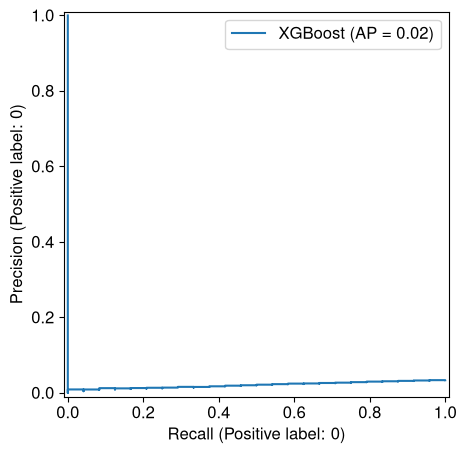

In [83]:
fig, ax = plt.subplots(figsize=(5,5))
# Precision Recall plot
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=0, name="XGBoost", ax=ax)
#ax.set_title("Precision recall curve for minority class")
ax.legend()
plt.savefig(Path.cwd() / "../report/pr_curve_min.eps", format="eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


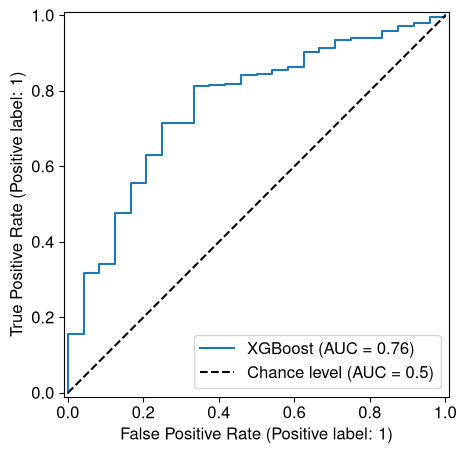

In [71]:
fig, ax = plt.subplots(figsize=(5,5))
RocCurveDisplay.from_predictions(y_test, test_probs[:, 1], name="XGBoost", ax=ax, plot_chance_level=True)
#RocCurveDisplay.from_predictions(y_test, dummy_probs[:, 1], name="Dummy baseline", ax=ax)
ax.legend()
plt.savefig(Path.cwd() / "../report/roc_auc.eps", format="eps")

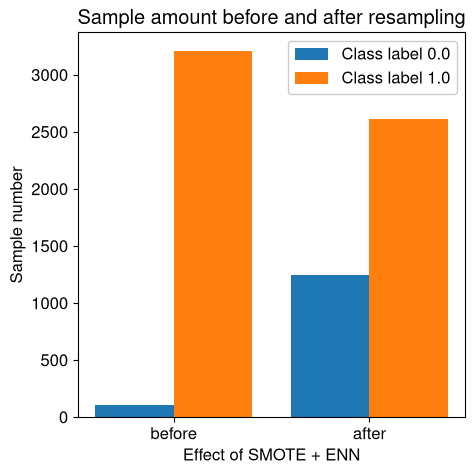

In [72]:
# SMOTE effect
before = Counter(y_exploration)
X_p = best_model.named_steps["pca"].fit_transform(X_exploration)
X_e, y_e = best_model.named_steps["smoteenn"].fit_resample(X_p, y_exploration)
after = Counter(y_e)

labels = sorted(before)
fig, ax = plt.subplots(figsize=(5,5))
x = np.arange(len(labels))
ax.bar(x-0.2, [before[0], after[0]], width=0.4, label="Class label 0.0")
ax.bar(x+0.2, [before[1], after[1]], width=0.4, label="Class label 1.0")
ax.set_xticks(x, ['before', 'after'])
ax.legend(loc="upper right", framealpha=1)
ax.set_xlabel("Effect of SMOTE + ENN")
ax.set_ylabel("Sample number")
ax.set_title("Sample amount before and after resampling")
plt.savefig(Path.cwd() / "../report/smote_effect.eps", format="eps")

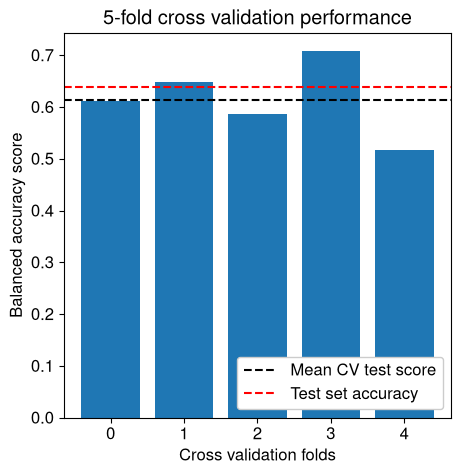

In [73]:
# CV Performance
best_idx = search.best_index_
fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(5)]

fig, ax = plt.subplots(figsize=(5,5))
ax.bar(range(5), fold_scores)
ax.axhline(search.cv_results_["mean_test_score"][best_idx], color="k", ls="--", label="Mean CV test score")
ax.axhline(balanced_accuracy_score(y_test, test_preds), color="r", ls="--", label="Test set accuracy")
ax.set_xlabel("Cross validation folds")
ax.set_ylabel("Balanced accuracy score")
ax.legend(loc="lower right", framealpha=1)
ax.set_title("5-fold cross validation performance")
plt.savefig(Path.cwd() / "../report/cv_performance.eps", format="eps")

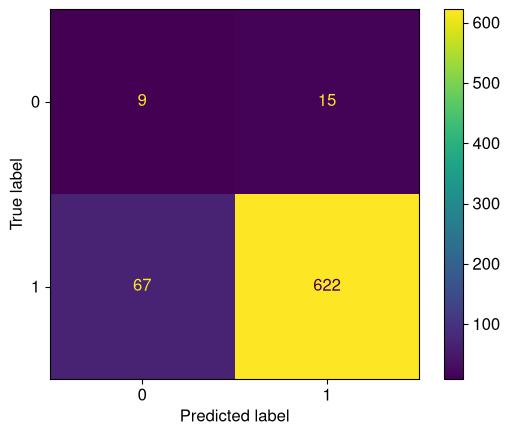

In [75]:
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.savefig(Path.cwd() / "../report/cm_test.eps", format="eps")
plt.show()

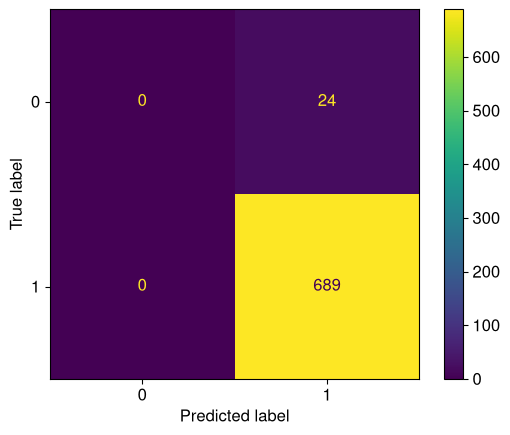

In [80]:
cm = confusion_matrix(y_test, dummy_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.savefig(Path.cwd() / "../report/cm_dummy.eps", format="eps")
plt.show()